<a href="https://colab.research.google.com/github/maitrungtung/IMIS_Machine_Learning/blob/main/Report/IMISToolA2026_Report5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Report 5 (2026/08/03 ver.A)

for Tools for intelligent interaction systems a (0ALE005 / 0AL5707).

---

* Student ID: 202520857
* Name: Tung Mai Trung
* Colab account: maitrungtung2602@gmail.com

---

Report could be written in English or Japanese. / レポートの記述は日本語でも英語でもよい．

---

**Note that this Report 5 is in conjunction with the IMIS Tool Exercise-A Lesson 700.  
Answers not linked with the Lesson 700 will be degraded.**  
https://github.com/kameda-yoshinari/IMISToolExeA/tree/main/700

---
# Report5A: Make your own classifier (Mandatory:必須)  

**Directly change "--" in this text cell to write a report.**

You are strongly encouraged to take images at your USB camera (or your smartphone camera).
(It is because the dataset would be obvious and trivial if you collect images by the google query with the word...)   
(DO NOT USE open dataset!)

* Show the link to the top google-drive folder of the image dataset (It should include train/Class1 train/Class2 val/Class1 val/Class2)

1. URL: -- (it should be accessible to kameda.yoshinari@image.iit.tsukuba.ac.jp / google account)

* Show the two class names you give.

1. Class1: --
2. Class2: --

* Number of images

1. Class1: --
2. Class2: --

* Three examples of test results (true label, two predicted labels of model_ft and model_conv, image)

1. Example1: --
2. Example2: --
3. Example3: --

Images should be given by URL that is accesible by kameda.yoshinari.ft@u.tsukuba.ac.jp, or inline image).


Write your findings of Report5A (Any comments are OK) below.

--

## **Report 5A — My Own Classifier**

This experiment follows the transfer-learning procedure introduced in **IMIS Tool Exercise-A Lesson 700**.

Lesson 700 introduces two approaches using a pretrained ResNet18:

- `model_ft`: fine-tuning all layers of the pretrained network.
- `model_conv`: using the pretrained network as a fixed feature extractor and training only the final classification layer.

I applied the same procedure to my own two-class image dataset. All images were taken by myself using a camera.

### Dataset

URL: **https://drive.google.com/drive/folders/1uDdgqlvsI8DscCtITQ8RIk_yfAwIx_jM?usp=drive_link**

Class1: **bottle**  
Class2: **calculator**

Number of images:

- bottle: 20 images = 15 training + 5 validation
- calculator: 20 images = 15 training + 5 validation

Dataset structure:

    train/
        bottle/
        calculator/
    val/
        bottle/
        calculator/

## **1. Preparation as Google Colab**


All the files will be placed on your Google Drive.

In [24]:
from google.colab import drive
drive.mount("/content/drive")

import os, time, copy, random
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim, torchvision
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
from torchvision import datasets, models, transforms
from PIL import Image

cudnn.benchmark = True
torch.manual_seed(0); np.random.seed(0); random.seed(0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch: 2.11.0+cu128
Device: cuda:0
GPU: Tesla T4


### **2. Loading and Preprocessing My Dataset**

Following Lesson 700, I use data augmentation for the training images and ImageNet normalization for both training and validation images.

Training images are randomly cropped and horizontally flipped, while validation images use deterministic resizing and center cropping. Both are converted into 224 × 224 RGB tensors suitable for the pretrained ResNet18 model.

In [11]:
data_dir = "/content/drive/MyDrive/IMIS_Tool-A/Work700/data/hymenoptera_data"

print("Dataset exists:", os.path.exists(data_dir))
if os.path.exists(data_dir):
    print("Train:", os.listdir(data_dir + "/train"))
    print("Val:", os.listdir(data_dir + "/val"))

Dataset exists: True
Train: ['bottle', 'calculator']
Val: ['bottle', 'calculator']


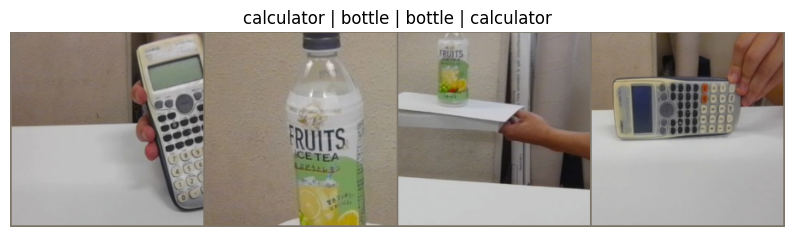

In [30]:
# Visualize some training images

inputs, classes = next(iter(dataloaders["train"]))
grid = torchvision.utils.make_grid(inputs)

img = grid.numpy().transpose((1, 2, 0))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = std * img + mean
img = np.clip(img, 0, 1)

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title(" | ".join(class_names[x] for x in classes))
plt.axis("off")
plt.show()

### **3. Dataset Tuning**

I use the same preprocessing strategy as Lesson 700.

For training, data augmentation is applied using random resized cropping and horizontal flipping. For validation, the images are resized and center-cropped without random augmentation.

The same ImageNet normalization values used in Lesson 700 are retained because the classifier uses an ImageNet-pretrained ResNet18.

In [31]:
data_transforms = {
    "train": transforms.Compose([transforms.RandomResizedCrop(224), transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    "val": transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
}

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir,x), data_transforms[x]) for x in ["train","val"]}

### **4. Data Loader**

Following Lesson 700, the images are loaded in mini-batches of four. The class names are automatically obtained from the folder names.

In [32]:
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=2) for x in ["train","val"]}
dataset_sizes = {x: len(image_datasets[x]) for x in ["train","val"]}
class_names = image_datasets["train"].classes

print("Dataset sizes:", dataset_sizes)
print("Class names:", class_names)
print("Device:", device)

Dataset sizes: {'train': 30, 'val': 10}
Class names: ['bottle', 'calculator']
Device: cuda:0


### **5. Checking the Loaded Training Images**

Before training, I visualize a batch of images to confirm that my bottle/calculator dataset is loaded and preprocessed correctly.

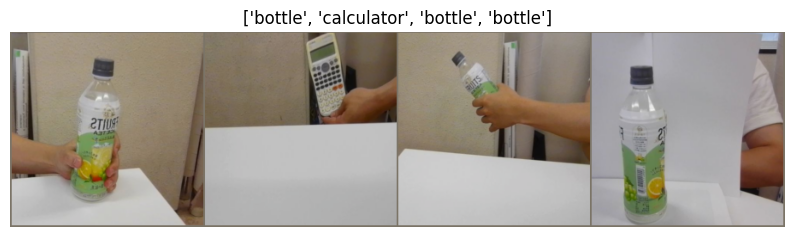

In [36]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1,2,0))
    inp = np.array([0.229,0.224,0.225])*inp + np.array([0.485,0.456,0.406])
    inp = np.clip(inp,0,1)
    plt.figure(figsize=(10,5)); plt.imshow(inp)
    if title is not None: plt.title(title)
    plt.axis("off"); plt.show()

inputs, classes = next(iter(dataloaders["train"]))
imshow(torchvision.utils.make_grid(inputs), title=[class_names[x] for x in classes])

## **6. Transfer Learning Following Lesson 700**

I now apply the two transfer-learning methods demonstrated in Lesson 700 to the same bottle/calculator dataset.

First, I train `model_ft` by fine-tuning the entire pretrained ResNet18. Then I train `model_conv` as a fixed feature extractor. The two models will later be evaluated using the same validation data and the same new camera images.

In [37]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time(); best_wts = copy.deepcopy(model.state_dict()); best_acc = 0.0
    history = {"train_loss":[],"train_acc":[],"val_loss":[],"val_acc":[]}

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-"*20)

        for phase in ["train","val"]:
            model.train() if phase=="train" else model.eval()
            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase=="train"):
                    outputs = model(inputs); _, preds = torch.max(outputs,1)
                    loss = criterion(outputs,labels)
                    if phase=="train": loss.backward(); optimizer.step()

                running_loss += loss.item()*inputs.size(0)
                running_corrects += torch.sum(preds==labels.data).item()

            if phase=="train": scheduler.step()

            epoch_loss = running_loss/dataset_sizes[phase]
            epoch_acc = running_corrects/dataset_sizes[phase]
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase=="val" and epoch_acc > best_acc:
                best_acc = epoch_acc; best_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_wts)
    print(f"\nTraining complete in {time.time()-since:.1f}s")
    print(f"Best val Acc: {best_acc:.4f}")
    return model, history, best_acc

### **7. Fine-tuning the ConvNet (`model_ft`)**

For the first Lesson 700 method, I initialize ResNet18 using pretrained ImageNet weights and replace the original final layer with a new layer for my two classes.

All layers remain trainable.

In [38]:
weights = models.ResNet18_Weights.DEFAULT
model_ft = models.resnet18(weights=weights)
model_ft.fc = nn.Linear(model_ft.fc.in_features, len(class_names))
model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)
scheduler_ft = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

model_ft, hist_ft, best_ft = train_model(model_ft, criterion, optimizer_ft, scheduler_ft, num_epochs=15)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 209MB/s]



Epoch 1/15
--------------------
train Loss: 0.7739 Acc: 0.4333
val Loss: 0.3777 Acc: 0.9000

Epoch 2/15
--------------------
train Loss: 0.4900 Acc: 0.7333
val Loss: 0.0776 Acc: 1.0000

Epoch 3/15
--------------------
train Loss: 0.9462 Acc: 0.6000
val Loss: 0.0301 Acc: 1.0000

Epoch 4/15
--------------------
train Loss: 0.5369 Acc: 0.7667
val Loss: 0.2324 Acc: 0.9000

Epoch 5/15
--------------------
train Loss: 0.1944 Acc: 0.9000
val Loss: 0.0017 Acc: 1.0000

Epoch 6/15
--------------------
train Loss: 0.0918 Acc: 1.0000
val Loss: 0.0012 Acc: 1.0000

Epoch 7/15
--------------------
train Loss: 0.3362 Acc: 0.8000
val Loss: 0.0014 Acc: 1.0000

Epoch 8/15
--------------------
train Loss: 0.5396 Acc: 0.7000
val Loss: 0.0012 Acc: 1.0000

Epoch 9/15
--------------------
train Loss: 0.0450 Acc: 1.0000
val Loss: 0.0009 Acc: 1.0000

Epoch 10/15
--------------------
train Loss: 0.1238 Acc: 0.9667
val Loss: 0.0009 Acc: 1.0000

Epoch 11/15
--------------------
train Loss: 0.2265 Acc: 0.9000
val 

### Checking `model_ft`

I first inspect several validation predictions produced by the fine-tuned model.

In [39]:
def visualize_model(model, num_images=6):
    model.eval(); shown = 0
    plt.figure(figsize=(12,7))

    with torch.no_grad():
        for inputs, labels in dataloaders["val"]:
            inputs = inputs.to(device); outputs = model(inputs); _, preds = torch.max(outputs,1)

            for j in range(inputs.size(0)):
                shown += 1
                ax = plt.subplot(2,3,shown); ax.axis("off")
                ax.set_title(f"pred: {class_names[preds[j]]}\ntrue: {class_names[labels[j]]}")
                img = inputs.cpu().data[j].numpy().transpose((1,2,0))
                img = np.array([0.229,0.224,0.225])*img + np.array([0.485,0.456,0.406])
                ax.imshow(np.clip(img,0,1))
                if shown == num_images: plt.tight_layout(); plt.show(); return

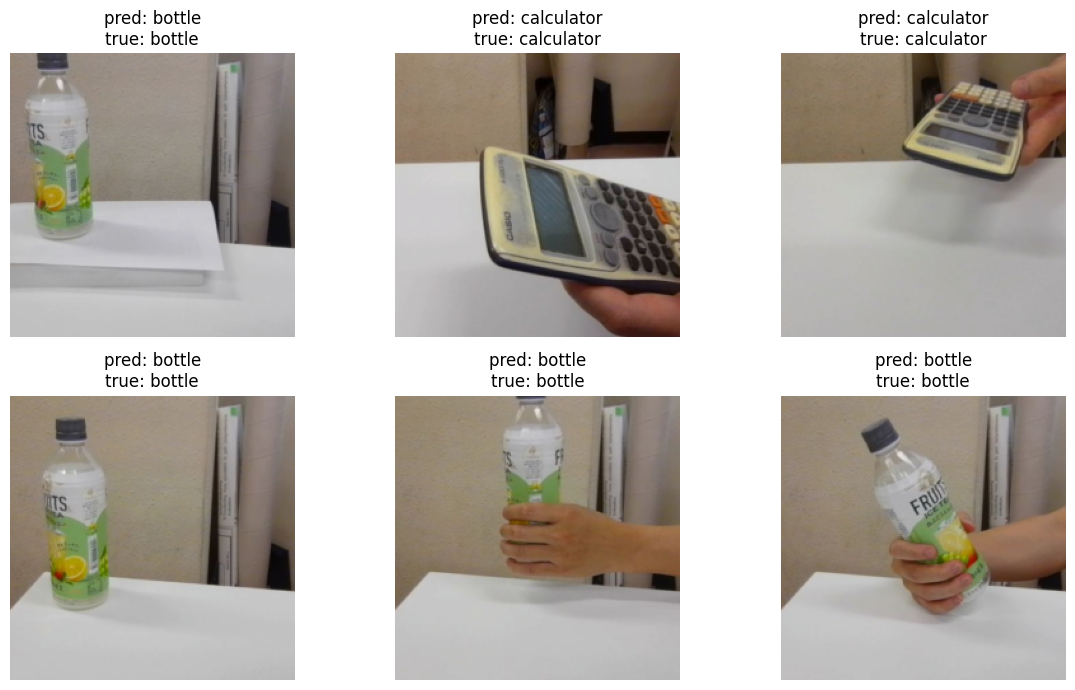

In [40]:
visualize_model(model_ft)

### **8. ConvNet as a Fixed Feature Extractor (`model_conv`)**

For the second Lesson 700 method, I freeze the pretrained ResNet18 parameters and train only the newly replaced final classification layer.

Therefore, the ImageNet feature extractor remains fixed while the final layer learns to distinguish bottle from calculator.

In [41]:
model_conv = models.resnet18(weights=weights)
for param in model_conv.parameters(): param.requires_grad = False

model_conv.fc = nn.Linear(model_conv.fc.in_features, len(class_names))
model_conv = model_conv.to(device)

optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)
scheduler_conv = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

model_conv, hist_conv, best_conv = train_model(model_conv, criterion, optimizer_conv, scheduler_conv, num_epochs=15)


Epoch 1/15
--------------------
train Loss: 0.9525 Acc: 0.3667
val Loss: 0.6577 Acc: 0.6000

Epoch 2/15
--------------------
train Loss: 0.8148 Acc: 0.5667
val Loss: 0.2872 Acc: 1.0000

Epoch 3/15
--------------------
train Loss: 0.5858 Acc: 0.6667
val Loss: 0.1091 Acc: 1.0000

Epoch 4/15
--------------------
train Loss: 0.3590 Acc: 0.8667
val Loss: 0.1132 Acc: 1.0000

Epoch 5/15
--------------------
train Loss: 0.3888 Acc: 0.8333
val Loss: 0.0541 Acc: 1.0000

Epoch 6/15
--------------------
train Loss: 0.5292 Acc: 0.7667
val Loss: 0.0466 Acc: 1.0000

Epoch 7/15
--------------------
train Loss: 0.5014 Acc: 0.7667
val Loss: 0.0970 Acc: 1.0000

Epoch 8/15
--------------------
train Loss: 0.2907 Acc: 0.8000
val Loss: 0.0368 Acc: 1.0000

Epoch 9/15
--------------------
train Loss: 0.3731 Acc: 0.8000
val Loss: 0.0253 Acc: 1.0000

Epoch 10/15
--------------------
train Loss: 0.2108 Acc: 0.9333
val Loss: 0.0263 Acc: 1.0000

Epoch 11/15
--------------------
train Loss: 0.3108 Acc: 0.8333
val 

### **Checking `model_conv`**

I also inspect validation predictions from the fixed-feature-extractor model before testing both models on completely new camera images.

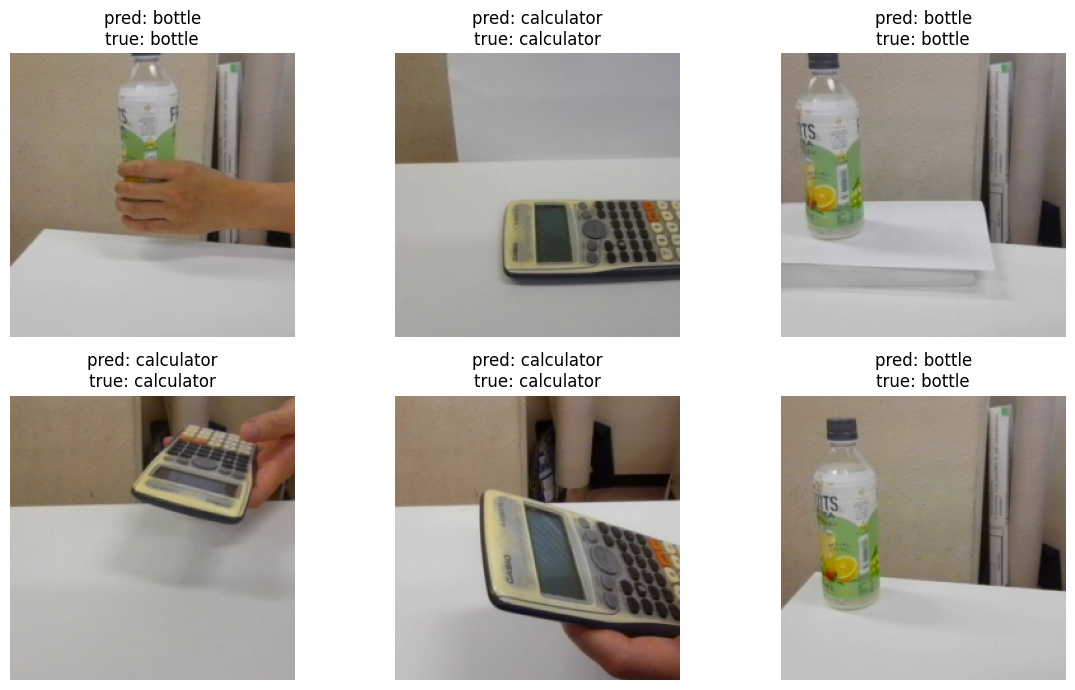

In [42]:
visualize_model(model_conv)

### **9. Comparison of the Two Lesson 700 Models**

Both models were trained on exactly the same bottle/calculator dataset. I compare their best validation accuracies below.

In [43]:
print("=== Validation Results ===")
print(f"model_ft   : {best_ft*100:.1f}%")
print(f"model_conv : {best_conv*100:.1f}%")

=== Validation Results ===
model_ft   : 100.0%
model_conv : 100.0%


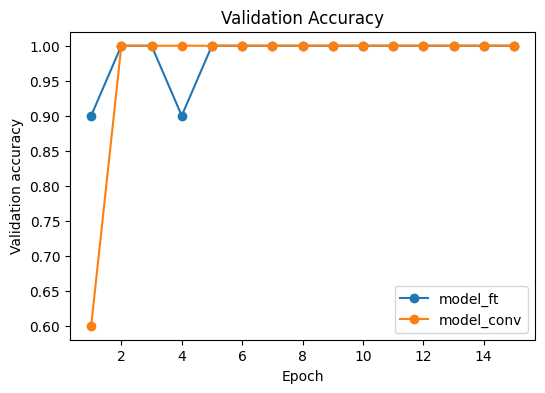

In [55]:
epochs = range(1,len(hist_ft["val_acc"])+1)
plt.figure(figsize=(6,4))
plt.plot(epochs,hist_ft["val_acc"],marker="o",label="model_ft")
plt.plot(epochs,hist_conv["val_acc"],marker="o",label="model_conv")
plt.xlabel("Epoch"); plt.ylabel("Validation accuracy")
plt.title("Validation Accuracy"); plt.legend(); plt.show()

## **10. Real-world Test with Unseen Objects**

Finally, I performed an additional real-world test using images captured directly with the camera.

Importantly, the bottle and calculator used in this test were **different physical objects from those used to create the training and validation datasets**. Therefore, these test images were not only new images, but also contained object instances that the models had never seen during training.

I also changed the object orientation in some images. For example, the new bottle was tested both vertically and horizontally.

The purpose of this experiment was to examine whether the classifiers could recognize the visual characteristics of the two object classes rather than simply recognizing the exact bottle and calculator used in the training dataset.

In [57]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename="photo.jpg", quality=0.9):
    js = Javascript('''
    async function takePhoto(q){
      const d=document.createElement("div"),v=document.createElement("video"),b=document.createElement("button");
      b.textContent="Capture"; d.append(v,b); document.body.appendChild(d);
      const s=await navigator.mediaDevices.getUserMedia({video:true}); v.srcObject=s; await v.play();
      await new Promise(r=>b.onclick=r);
      const c=document.createElement("canvas"); c.width=v.videoWidth; c.height=v.videoHeight;
      c.getContext("2d").drawImage(v,0,0); s.getTracks().forEach(t=>t.stop()); d.remove();
      return c.toDataURL("image/jpeg",q);
    }''')
    display(js); data=eval_js(f"takePhoto({quality})")
    with open(filename,"wb") as f: f.write(b64decode(data.split(",")[1]))
    return filename

In [66]:
results = []

for i in range(4):
    print(f"\n===== TEST IMAGE {i+1}/4 =====")

    filename = take_photo(f"report5_test_{i+1}.jpg")
    image = Image.open(filename).convert("RGB")

    true_label = input("True label (bottle/calculator): ").strip().lower()

    ft, ft_conf = predict_image(model_ft, image)
    conv, conv_conf = predict_image(model_conv, image)
    results.append((image, true_label, ft, ft_conf, conv, conv_conf))

    print(f"True       : {true_label}")
    print(f"model_ft   : {ft} ({ft_conf:.2f}%)")
    print(f"model_conv : {conv} ({conv_conf:.2f}%)")


===== TEST IMAGE 1/4 =====


<IPython.core.display.Javascript object>

True label (bottle/calculator): bottle
True       : bottle
model_ft   : bottle (90.87%)
model_conv : bottle (73.63%)

===== TEST IMAGE 2/4 =====


<IPython.core.display.Javascript object>

True label (bottle/calculator): bottle
True       : bottle
model_ft   : bottle (60.89%)
model_conv : bottle (50.23%)

===== TEST IMAGE 3/4 =====


<IPython.core.display.Javascript object>

True label (bottle/calculator): calculator
True       : calculator
model_ft   : calculator (91.85%)
model_conv : calculator (89.25%)

===== TEST IMAGE 4/4 =====


<IPython.core.display.Javascript object>

True label (bottle/calculator): calculator
True       : calculator
model_ft   : calculator (90.09%)
model_conv : calculator (94.88%)


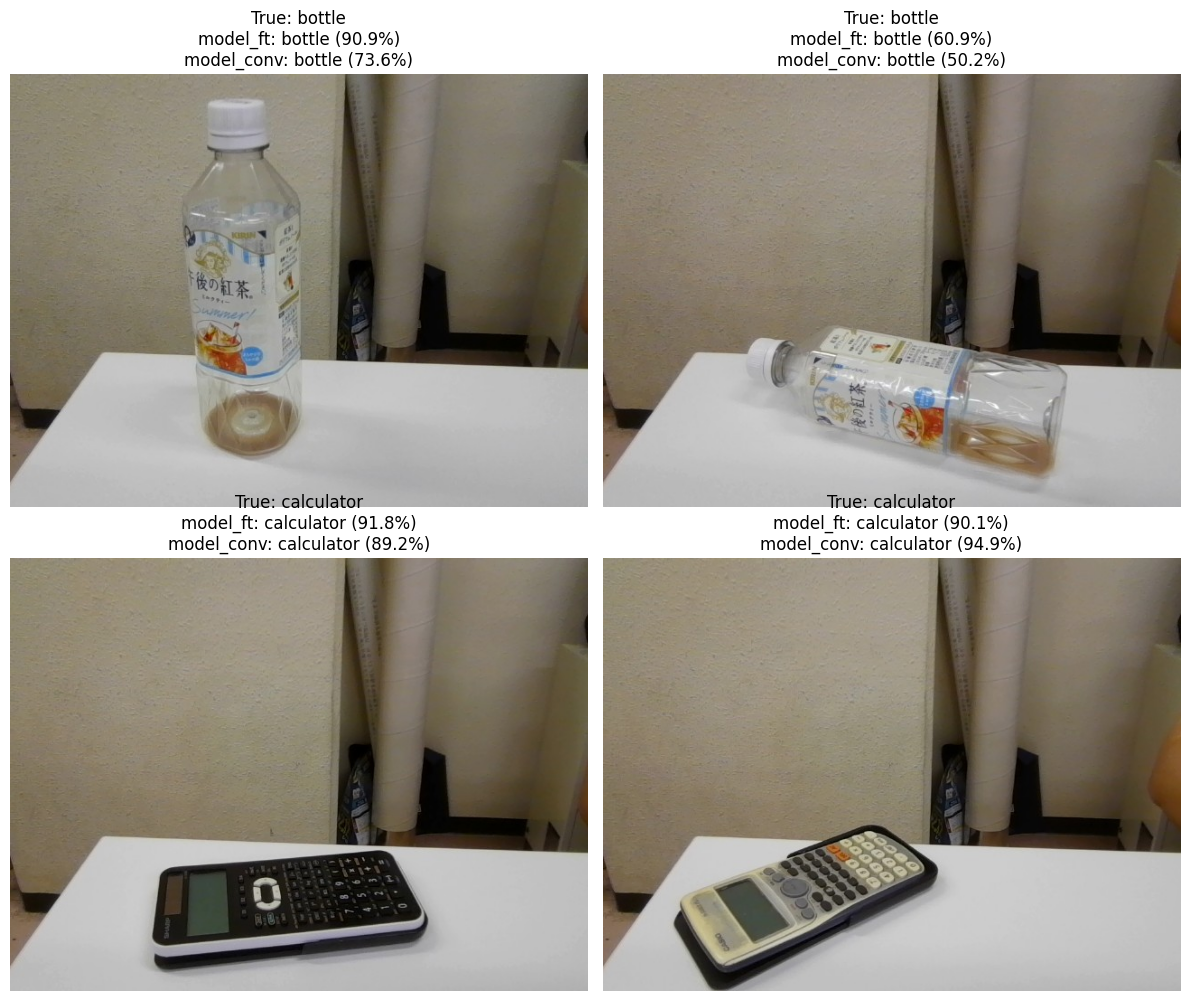

In [67]:
plt.figure(figsize=(12,10))
for i,(img,true,ft,fc,conv,cc) in enumerate(results):
    plt.subplot(2,2,i+1); plt.imshow(img)
    plt.title(f"True: {true}\nmodel_ft: {ft} ({fc:.1f}%)\nmodel_conv: {conv} ({cc:.1f}%)")
    plt.axis("off")
plt.tight_layout(); plt.show()

### **11. Camera Test Results**

The following results compare the two Lesson 700 models on the same four new camera images.

In [62]:
print(f"{'Test':<6}{'True':<13}{'model_ft':<15}{'model_conv':<15}")
print("-"*49)
for i,(_,true,ft,fc,conv,cc) in enumerate(results,1):
    print(f"{i:<6}{true:<13}{ft:<15}{conv:<15}")

Test  True         model_ft       model_conv     
-------------------------------------------------
1     bottle       bottle         bottle         
2     calculator   calculator     calculator     
3     bottle       bottle         calculator     
4     calculator   calculator     calculator     


## **Three Test Examples**

### Example 1 — Unseen bottle
- True label: **bottle**
- `model_ft`: **bottle (90.87%)**
- `model_conv`: **bottle (73.63%)**

This bottle was different from the bottle used in the training and validation dataset. Both models correctly classified the unseen bottle.

### Example 2 — Unseen bottle with a different orientation
- True label: **bottle**
- `model_ft`: **bottle (60.89%)**
- `model_conv`: **bottle (50.23%)**

The unseen bottle was placed horizontally. Both models still produced the correct prediction, although the confidence of both models decreased considerably.

### Example 3 — Unseen calculator
- True label: **calculator**
- `model_ft`: **calculator (91.85%)**
- `model_conv`: **calculator (89.25%)**

This calculator was also different from the calculator used in the training and validation dataset. Both models correctly classified the unseen calculator with high confidence.

## **Findings of Report5A**

I created my own two-class image dataset consisting of `bottle` and `calculator` images and trained two classifiers following the transfer-learning procedure of Lesson 700: `model_ft` and `model_conv`.

After training and validation, I performed an additional camera test using a different physical bottle and a different physical calculator from those used in the training and validation datasets. Therefore, the models had never seen these exact objects during training.

Both `model_ft` and `model_conv` correctly classified all four camera images. In particular, the new calculator was recognized with high confidence by both models. The new bottle was also correctly recognized in both vertical and horizontal orientations.

An interesting observation was that changing the bottle orientation reduced the confidence. For the vertical bottle, `model_ft` and `model_conv` obtained 90.87% and 73.63%, respectively. When the bottle was placed horizontally, the confidence decreased to 60.89% and 50.23%, although both predictions remained correct.

These results suggest that the classifiers learned some visual features associated with the `bottle` and `calculator` classes rather than simply memorizing the exact objects in the training images.

However, the dataset and the number of camera tests are small. Therefore, the 4/4 correct results should not be interpreted as a general 100% classification accuracy. A larger independent test dataset would be required for a reliable performance evaluation.

---
# Report5X: Evaluate the performance by "test" dataset (Optional:発展)  

Prepare 10 test images that take either of the two class objects (or other if you prefer, in this case, the 3rd label should be "other") and measure the performance of the two classifiers (of model_ft and model_conv).

* The images should be placed at the same folder as shown in 5A. (e.g. test/Class1 test/Class2 test/other)
* The total number of images in test/ folder should be 10 or more.
* Show the accuracy for the 10 images for both model_ft and model_conv.
* Carefully write the table and the report so as to be easy to read.


Report of 5X should be placed by changing this text cell (you can add more cells if you need).

---
# Report5Y: Evaluate the performance by changing the training (and validation) dataset (Optional:発展)  

By changinge the number of the images in train / validation, show the classification ratio for each.

* The number changing policy is up to the student.
* Write the way to select the images.
* Discuss what you expect before you start and what actually happend in the experimental result.
* Guess the reason if you encounter the expectation does not become true.


Report of 5Y should be placed by changing this text cell (you can add more cells if you need).

---
# Report5Z: Hide the objects and see what happens on the classifiers (Optional:発展)  

You may think the classifier could be build even when the objects are deleted from the training images as the some peripheral areas might have the biased image property correlated to the object.

* Delete (black out) the objects roughly in the training images.
* Run the same process of 5A, and 5X / 5Y if possible.
* Discuss what you expect before you start and what actually happend in the experimental result.
* Justify the reason of what actually happend.

Further reading:


[Object Recognition with and without Objects (2016)](https://arxiv.org/abs/1611.06596)  
[Noise or Signal: The Role of Image Backgrounds in Object Recognition (2017)](https://arxiv.org/abs/2006.09994)  
  

A discussion before AI/DL age  
[物体検出 — 背景と検出対象のモデリング — (2005)](https://vision.kuee.kyoto-u.ac.jp/japanese/happyou/pdf/Sumi_2005_P_197.pdf)

Report of 5Z should be placed by changing this text cell (you can add more cells if you need).

---
# Report submission

The report template will be given in ipynb file.  

You should save this file as a report templete to your local google colaboratory folder and then edit it to fit your report.

The report submission should be made at this cource (0ALE005) at https://manaba.tsukuba.ac.jp .  
Note that 0AL5707 is coupled with 0ALE005 on manaba system, so 0AL5707 students should also submit the report at 0ALE005.  
File extension should be **ipynb**. Other format won't be accepted.  








---
Tools and Practices for Intelligent Interaction Systems A  
Master's and Docotal programs in intelligent and mechanical interaction systems, University of Tsukuba, Japan.  
KAMEDA Yoshinari, SHIBUYA Takeshi  

知能システムツール演習a  
知能機能システム学位プログラム (筑波大学大学院)  
担当：亀田能成，澁谷長史  

2026/08/03. Ver.A.  


